# Lecture 1 — The spelled-out intro to neural networks and backpropagation: building micrograd

Following [Karpathy's Neural Networks: Zero to Hero](https://www.youtube.com/watch?v=VMj-3S1tku0)

**What we build:** `micrograd` — a tiny scalar-valued autograd engine + a neural net library on top of it.

**Core idea:** every operation (+, *, tanh, ...) builds a computation graph. We can then call `.backward()` to propagate gradients from the loss all the way back to the inputs via the **chain rule**.

**Audio application at the end:** we use our MLP to classify audio features (spectral centroid, RMS energy, zero-crossing rate) of synthetically generated soundscapes.

## 0. Setup

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. What is a derivative? (the intuition)

Before building anything, let's make sure the intuition is rock solid.
A derivative tells us: if I nudge the input by a tiny `h`, how much does the output change?

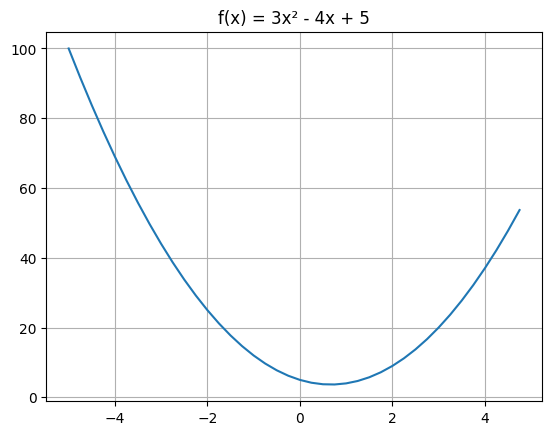

In [5]:
def f(x):
    return 3*x**2 - 4*x + 5

# plot it
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.title('f(x) = 3x² - 4x + 5')
plt.grid(True)
plt.show()

In [6]:
# numerical derivative: (f(x+h) - f(x)) / h  as h -> 0
x = 3.0
h = 0.001
numerical_grad = (f(x + h) - f(x)) / h
print(f'f(x)={f(x):.4f}')
print(f'f(x+h)={f(x+h):.4f}')
print(f'f(x+h)-f(x)={f(x+h)-f(x):.4f}')
print(f'(f(x+h)-f(x))/h={(f(x+h)-f(x))/h:.4f}')
print(f'numerical derivative at x={x}: {numerical_grad:.4f}')
# analytical: f'(x) = 6x - 4 => at x=3 => 14
print(f'analytical derivative at x={x}: {6*x - 4}')

f(x)=20.0000
f(x+h)=20.0140
f(x+h)-f(x)=0.0140
(f(x+h)-f(x))/h=14.0030
numerical derivative at x=3.0: 14.0030
analytical derivative at x=3.0: 14.0


In [7]:
# now a function of multiple inputs — the same idea applies
# we want df/da, df/db, df/dc

a = 2.0; b = -3.0; c = 10.0

def compute(a, b, c):
    return a*b + c

d = compute(a, b, c)
print(f'd = {d}')

h = 0.0001
print(f'dd/da = {(compute(a+h, b, c) - d) / h:.4f}')  # should be b = -3
print(f'dd/db = {(compute(a, b+h, c) - d) / h:.4f}')  # should be a = 2
print(f'dd/dc = {(compute(a, b, c+h) - d) / h:.4f}')  # should be 1

d = 4.0
dd/da = -3.0000
dd/db = 2.0000
dd/dc = 1.0000


## 2. The `Value` class — building the autograd engine

We wrap scalars in a `Value` object that:
- stores the data (the forward pass result)
- remembers its children in the compute graph (`_children`)
- stores the gradient `.grad` (initialized to 0)
- stores a `_backward` function that knows how to propagate gradients

In [8]:
class Value:
    """Stores a single scalar value and its gradient."""
    #data is the data you feed
    #children is to keep track of what values produce what other values (empty tuple)
    #op is which operatino produced a result
    #label tells us what variables we are working with
    # .grad maintains the derivative of the output (L) with respect to that value
    # to make L go up we nudge a,b,c,d,e by a tiny amount in the direction of the gradient
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0          # gradient of loss w.r.t. this node
        self._backward = lambda: None  # how to backprop through this node
        self._prev = set(_children) #this is the set of children
        self._op = _op           # which operation created this node (for debug)
        self.label = label

    # function that python uses to return the data in a nicer looking way
    def __repr__(self):
        return f'Value(data={self.data:.4f}, grad={self.grad:.4f})'

    # --- forward ops ---

    # how to add 2 value objects (__ __ are operators_)
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        #because + routes the derivative (=1), it's just self.grad
        def _backward():
            # d(out)/d(self) = 1, d(out)/d(other) = 1
            # chain rule: self.grad += out.grad * 1
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    # implement multuply
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        # other is a constant (int or float), not a Value
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        # math.tanh handles large values correctly — avoids overflow
        t = math.tanh(x)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'relu')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    # --- sugar ---

    def __neg__(self):         return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other):  return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    # --- backward pass ---
    # when we implement backpropagation we look at the derivative of L (loss function) with respect
    # to a, b, c, d, e. In NN, we will have weights instead of these numbers

    # topological sort allows us to not comupte backpropagation until everything
    # after a certain node has been forward propagated. All the edges need to go
    # from left to right
    def backward(self):
        """Topological sort + reverse-mode autodiff."""
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                # visit all the children
                for child in v._prev:
                    build_topo(child)
                # adds itslef
                topo.append(v)
        build_topo(self)

        # and now in reverse topological order compute backward prop
        self.grad = 1.0  # dL/dL = 1
        for node in reversed(topo):
            node._backward()

### Quick sanity check

In [9]:
# simple expression: L = (a * b + c).tanh()
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
L = d.tanh(); L.label = 'L'

print('Forward pass:')
print(f'  e = a*b = {e.data}')
print(f'  d = e+c = {d.data}')
print(f'  L = tanh(d) = {L.data:.4f}')

L.backward()

print('\nGradients (dL/d...):')
print(f'  a.grad = {a.grad:.4f}  (numerical check: ~{(((Value(2+1e-4)*b + c).tanh()).data - L.data)/1e-4:.4f})')
print(f'  b.grad = {b.grad:.4f}')
print(f'  c.grad = {c.grad:.4f}')

Forward pass:
  e = a*b = -6.0
  d = e+c = 4.0
  L = tanh(d) = 0.9993

Gradients (dL/d...):
  a.grad = -0.0040  (numerical check: ~-0.0040)
  b.grad = 0.0027
  c.grad = 0.0013


## 3. Visualize the computation graph

Install graphviz to see the actual graph Karpathy draws on screen.

In [10]:
!pip install graphviz -q

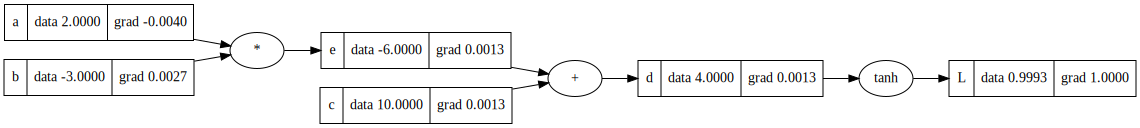

In [11]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,
                 label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

draw_dot(L)

## 4. Manual backprop — the neuron example

Let's manually verify gradients for a single neuron:

```
output = tanh(w1*x1 + w2*x2 + b)
```

Forward pass: o = 0.7071067811865477

Gradients:
x1.grad = -1.5000
x2.grad = 0.5000
w1.grad = 1.0000
w2.grad = 0.0000


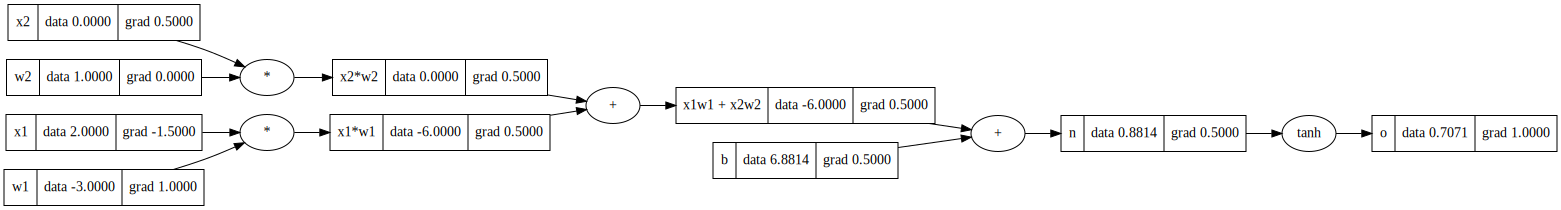

In [12]:
# A neuron is modelled mathematically as a set of inputs and weights (synapses) xn*wn,
# then there is a bias b (happyness of the neuron) and finally an activation function
# a squashing function like a sigmoid or tanh

# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')  # chosen to make output ~0.707

# neuron forward pass
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

print('Forward pass: o =', o.data)

# backward
o.backward()

print('\nGradients:')
print(f'x1.grad = {x1.grad:.4f}')
print(f'x2.grad = {x2.grad:.4f}')
print(f'w1.grad = {w1.grad:.4f}')
print(f'w2.grad = {w2.grad:.4f}')

draw_dot(o)

## 5. Cross-check with PyTorch

In [13]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b  = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
o.backward()

print('PyTorch gradients:')
print(f'x1.grad = {x1.grad.item():.4f}')
print(f'x2.grad = {x2.grad.item():.4f}')
print(f'w1.grad = {w1.grad.item():.4f}')
print(f'w2.grad = {w2.grad.item():.4f}')
# should match our micrograd results exactly

PyTorch gradients:
x1.grad = -1.5000
x2.grad = 0.5000
w1.grad = 1.0000
w2.grad = 0.0000


## 6. Build the neural net library

Now we build `Neuron`, `Layer`, `MLP` on top of `Value`.

In [14]:
import random

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []


class Neuron(Module):
    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'Tanh' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


class Layer(Module):
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


class MLP(Module):
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=(i != len(nouts)-1))
                       for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(l) for l in self.layers)}]"

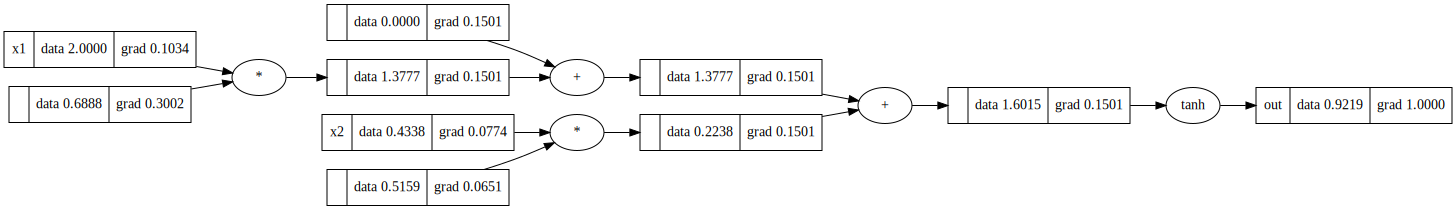

In [15]:
# --- visualize a single neuron ---
# exactly what Karpathy does: draw_dot(n(x))
# one Neuron with 2 inputs, one forward pass, then draw the graph

random.seed(0)
n = Neuron(2)
x = [Value(2.0, label='x1'), Value(0.4338, label='x2')]  # same values as in the video
out = n(x)
out.label = 'out'
out.backward()
draw_dot(out)

## 7. Train on a toy dataset

In [16]:
# 4 training examples, 3 inputs each
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

model = MLP(3, [4, 4, 1])
print(model)
print(f'Number of parameters: {len(model.parameters())}')

MLP of [Layer of [TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3)], Layer of [TanhNeuron(4), TanhNeuron(4), TanhNeuron(4), TanhNeuron(4)], Layer of [LinearNeuron(4)]]
Number of parameters: 41


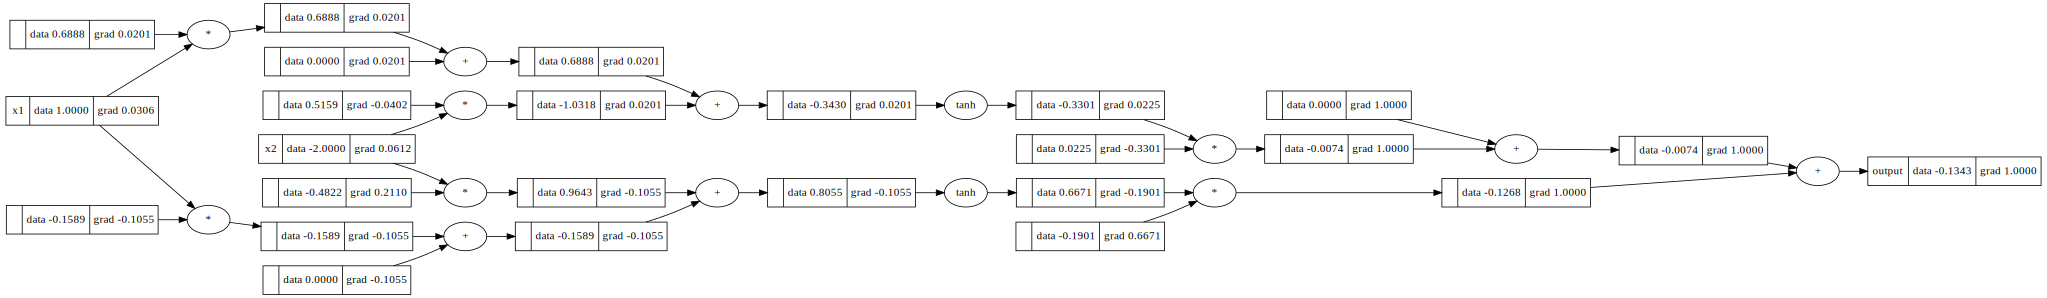

In [17]:
# --- now the full MLP — same idea, just deeper ---
# MLP(2,[2,1]): small enough to still be readable
random.seed(0)
viz_model = MLP(2, [2, 1])
x_viz = [Value(1.0, label='x1'), Value(-2.0, label='x2')]
o_viz = viz_model(x_viz)
o_viz.label = 'output'
o_viz.backward()
draw_dot(o_viz)

step   0  loss=8.2187  preds=[-0.64, 0.24, 0.25, -0.55]
step  10  loss=0.0004  preds=[1.0, -1.01, -0.98, 1.0]
step  20  loss=0.0000  preds=[1.0, -1.0, -1.0, 1.0]
step  30  loss=0.0000  preds=[1.0, -1.0, -1.0, 1.0]
step  40  loss=0.0000  preds=[1.0, -1.0, -1.0, 1.0]


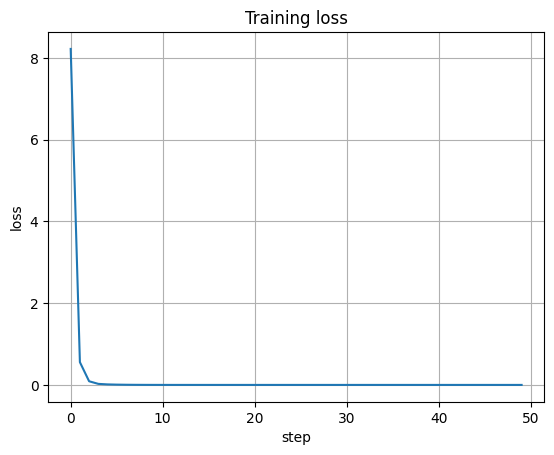

In [18]:
losses = []

for step in range(50):
    # ---- forward pass ----
    ypred = [model(x) for x in xs]
    # MSE loss
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    # ---- backward pass ----
    model.zero_grad()   # reset gradients!
    loss.backward()

    # ---- update (gradient descent) ----
    # we have a negative sign as we go in the opposite direction of the loss to minimize it
    lr = 0.05
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(loss.data)
    if step % 10 == 0:
        print(f'step {step:3d}  loss={loss.data:.4f}  preds={[round(y.data, 2) for y in ypred]}')

plt.plot(losses)
plt.xlabel('step'); plt.ylabel('loss'); plt.title('Training loss'); plt.grid(True)
plt.show()

---
# 🎧 Audio Application — Soundscape Classifier

**Idea:** apply our micrograd MLP to classify audio features extracted from synthetic soundscapes.

We generate 3 soundscape classes:
- **Rain**
- **Wind**
- **Forest**

For each audio clip we extract 3 hand-crafted features:
1. **RMS energy** — loudness
2. **Spectral centroid** — brightness (where the energy is concentrated in frequency)
3. **Zero-crossing rate** — how often the signal crosses zero (correlates with noisiness/frequency content)

Then we train our micrograd MLP to classify these features.

**Why this matters:** these same features are used in real audio ML pipelines. They're the "old school" version of learned embeddings — understanding them gives you intuition for what neural nets later learn automatically.

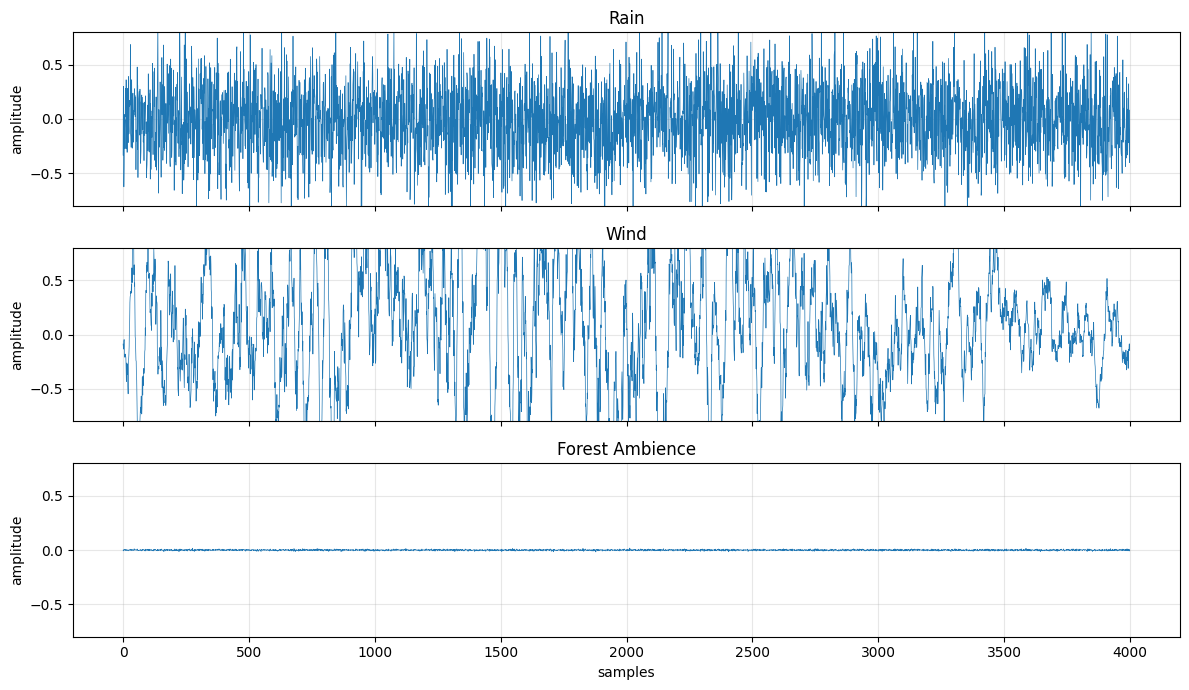

In [19]:
# --- synthetic audio generation ---
import numpy as np

SR = 22050  # sample rate
DURATION = 1.0  # seconds
N = int(SR * DURATION)

rng = np.random.default_rng(42)

def generate_rain(n=N, rng=rng):
    """Rain at variable intensity — drizzle to heavy downpour.
    Structurally: broadband white noise. The key feature is high ZCR (~0.5)
    and a FLAT spectrum (energy spread equally across all frequencies).
    Amplitude varies: light rain can sound similar in loudness to wind.
    """
    intensity = rng.uniform(0.05, 0.40)
    return rng.normal(0, intensity, n).astype(np.float32)

def generate_wind(n=N, rng=rng):
    """Wind at variable intensity — breeze to gust.
    Structurally: amplitude-modulated low-pass noise.
    Key features: very LOW ZCR (slow oscillations), LOW spectral centroid.
    Can overlap with rain in RMS — a strong gust is as loud as light rain.
    """
    noise = rng.normal(0, 1, n)
    kernel_size = int(rng.integers(20, 300))
    kernel = np.ones(kernel_size) / kernel_size
    filtered = np.convolve(noise, kernel, mode='same')
    t = np.linspace(0, DURATION, n)
    gust_freq = rng.uniform(0.5, 4.0)
    envelope = rng.uniform(0.3, 0.7) + rng.uniform(0.2, 0.5) * np.sin(2*np.pi*gust_freq*t)
    amplitude = rng.uniform(0.5, 3.5)
    return np.clip(filtered * envelope * amplitude, -1, 1).astype(np.float32)

def generate_forest_ambience(n=N, rng=rng):
    """Forest — sparse chirps on a quiet background.
    Variable chirp density: sometimes 1-2 distant birds (quiet),
    sometimes a dense chorus (can sound busy). Slight noise floor.
    Key feature: mid-to-high spectral centroid, ZCR similar to rain (tricky!).
    """
    background = rng.uniform(0.001, 0.02) * rng.normal(0, 1, n)
    signal = background.copy()
    n_chirps = int(rng.integers(1, 15))
    for _ in range(n_chirps):
        start = int(rng.integers(0, max(1, n - SR//10)))
        dur = int(rng.integers(SR//40, SR//8))
        f1, f2 = rng.uniform(500, 8000), rng.uniform(500, 8000)
        chirp_t = np.arange(dur) / SR
        phase = np.cumsum(2 * np.pi * np.linspace(f1, f2, dur) / SR)
        chirp = rng.uniform(0.05, 0.25) * np.sin(phase) * np.hanning(dur)
        end = min(start + dur, n)
        signal[start:end] += chirp[:end-start].astype(np.float32)
    return np.clip(signal, -1, 1).astype(np.float32)

# visualize one example of each
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
soundscapes = [('Rain', generate_rain), ('Wind', generate_wind), ('Forest Ambience', generate_forest_ambience)]
for ax, (name, gen) in zip(axes, soundscapes):
    sig = gen()
    ax.plot(sig[:4000], linewidth=0.5)
    ax.set_title(name); ax.set_ylim(-0.8, 0.8)
    ax.set_ylabel('amplitude'); ax.grid(True, alpha=0.3)
plt.xlabel('samples'); plt.tight_layout(); plt.show()


In [20]:
# --- listen to the soundscapes ---
from IPython.display import Audio, display

print('🌧️  Rain — broadband noise, variable intensity')
display(Audio(generate_rain(), rate=SR))

print('💨  Wind — low-frequency, amplitude-modulated gusts')
display(Audio(generate_wind(), rate=SR))

print('🌲  Forest Ambience — sparse chirps on quiet background')
display(Audio(generate_forest_ambience(), rate=SR))


🌧️  Rain — broadband noise, variable intensity


💨  Wind — low-frequency, amplitude-modulated gusts


🌲  Forest Ambience — sparse chirps on quiet background


In [21]:
# --- feature extraction ---

def rms_energy(signal):
    return float(np.sqrt(np.mean(signal**2)))

def spectral_centroid(signal, sr=SR):
    """Frequency-weighted average of the magnitude spectrum."""
    spectrum = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), d=1/sr)
    total = spectrum.sum()
    if total < 1e-10:
        return 0.0
    centroid = float(np.sum(freqs * spectrum) / total)
    return centroid / (sr / 2)  # normalize to [0, 1]

def zero_crossing_rate(signal):
    signs = np.sign(signal)
    zcr = np.sum(np.abs(np.diff(signs))) / (2 * len(signal))
    return float(zcr)

def extract_features(signal):
    return [
        rms_energy(signal),
        spectral_centroid(signal),
        zero_crossing_rate(signal),
    ]

# demo
for name, gen in [('Rain', generate_rain), ('Wind', generate_wind), ('Forest', generate_forest_ambience)]:
    sig = gen()
    feats = extract_features(sig)
    print(f'{name:10s} | rms={feats[0]:.4f}  centroid={feats[1]:.4f}  zcr={feats[2]:.4f}')

Rain       | rms=0.1856  centroid=0.5014  zcr=0.4973
Wind       | rms=0.0574  centroid=0.1503  zcr=0.0280
Forest     | rms=0.0603  centroid=0.3995  zcr=0.4547


Train: 180 samples (-60 rain, 120 non-rain)
Test:  120  samples (-40 rain, 80 non-rain)


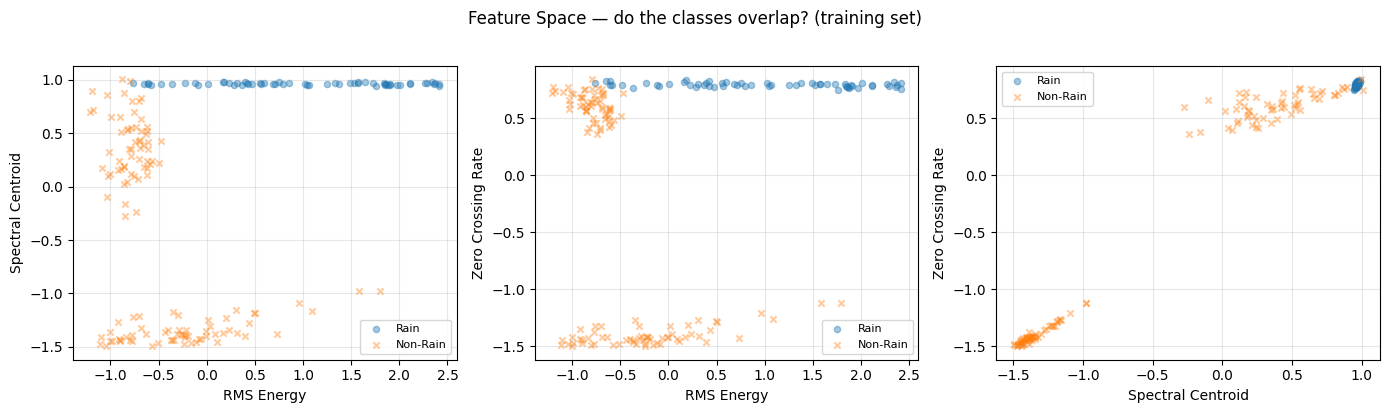

In [22]:
# --- build dataset with train/test split ---
# Binary: rain (+1) vs non-rain (-1)
#
# The key question we avoided before: is the problem actually hard?
# With fixed-amplitude synthetic sounds, RMS alone perfectly separates classes
# and the network learns nothing interesting. We fix this by:
#   1. Variable amplitude per sample (distributions OVERLAP in RMS)
#   2. Proper train/test split — so we can measure false positives AND false negatives
#   3. Confusion matrix instead of just accuracy

N_TRAIN = 60  # per class
N_TEST  = 40  # per class

def make_dataset(n_per_class, seed_offset=0):
    local_rng = np.random.default_rng(42 + seed_offset)
    X, y = [], []
    for _ in range(n_per_class):
        X.append(extract_features(generate_rain(rng=local_rng)))
        y.append(1.0)
    for _ in range(n_per_class):
        X.append(extract_features(generate_wind(rng=local_rng)))
        y.append(-1.0)
    for _ in range(n_per_class):
        X.append(extract_features(generate_forest_ambience(rng=local_rng)))
        y.append(-1.0)
    return np.array(X), np.array(y)

X_train_raw, y_train = make_dataset(N_TRAIN, seed_offset=0)
X_test_raw,  y_test  = make_dataset(N_TEST,  seed_offset=100)  # different rng seed!

# normalize using TRAIN statistics only (no data leakage)
X_mean = X_train_raw.mean(axis=0)
X_std  = X_train_raw.std(axis=0) + 1e-8
X_train = (X_train_raw - X_mean) / X_std
X_test  = (X_test_raw  - X_mean) / X_std  # same normalization!

print(f'Train: {len(X_train)} samples ({int(y_train.sum())} rain, {int((y_train==-1).sum())} non-rain)')
print(f'Test:  {len(X_test)}  samples ({int(y_test.sum())} rain, {int((y_test==-1).sum())} non-rain)')

# visualize feature space — do the classes overlap?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
feature_names = ['RMS Energy', 'Spectral Centroid', 'Zero Crossing Rate']
pairs = [(0,1),(0,2),(1,2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(X_train[y_train== 1, i], X_train[y_train== 1, j], label='Rain',     alpha=0.4, s=20)
    ax.scatter(X_train[y_train==-1, i], X_train[y_train==-1, j], label='Non-Rain', alpha=0.4, s=20, marker='x')
    ax.set_xlabel(feature_names[i]); ax.set_ylabel(feature_names[j])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Feature Space — do the classes overlap? (training set)', y=1.02)
plt.tight_layout(); plt.show()

xs_audio = [list(x) for x in X_train]
ys_audio = list(y_train)
xs_test  = [list(x) for x in X_test]
ys_test  = list(y_test)


MLP of [Layer of [TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3), TanhNeuron(3)], Layer of [TanhNeuron(8), TanhNeuron(8), TanhNeuron(8), TanhNeuron(8), TanhNeuron(8), TanhNeuron(8), TanhNeuron(8), TanhNeuron(8)], Layer of [LinearNeuron(8)]]
Parameters: 113
step   0 | loss=152.213 | train_acc=63.9% | test_acc=95.8%
step  10 | loss=38.403 | train_acc=96.7% | test_acc=91.7%
step  20 | loss=24.025 | train_acc=97.8% | test_acc=92.5%
step  30 | loss=20.278 | train_acc=97.8% | test_acc=95.8%
step  40 | loss=18.133 | train_acc=97.8% | test_acc=95.8%
step  50 | loss=15.454 | train_acc=97.8% | test_acc=95.8%
step  60 | loss=14.022 | train_acc=97.8% | test_acc=95.8%
step  70 | loss=13.462 | train_acc=98.3% | test_acc=96.7%
step  80 | loss=12.372 | train_acc=98.3% | test_acc=96.7%
step  90 | loss=12.029 | train_acc=98.3% | test_acc=96.7%
step 100 | loss=11.510 | train_acc=98.3% | test_acc=96.7%
step 110 | loss=11.203 | train_acc=98.9% | test

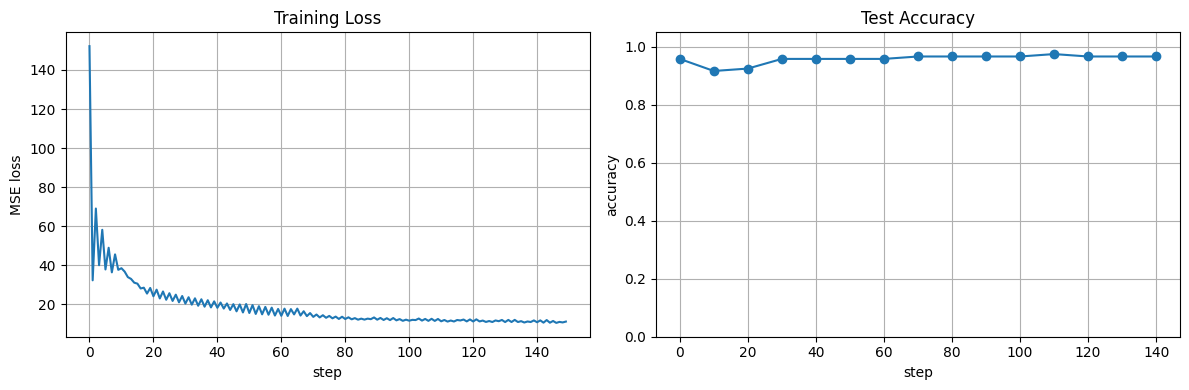

In [23]:
# --- train with our micrograd MLP ---
random.seed(1337)

audio_model = MLP(3, [8, 8, 1])
print(audio_model)
print(f'Parameters: {len(audio_model.parameters())}')

train_losses, test_accs = [], []

for step in range(150):
    # forward
    ypred = [audio_model(x) for x in xs_audio]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys_audio, ypred)])

    # backward
    audio_model.zero_grad()
    loss.backward()

    # gradient descent with clipping
    lr = 0.01
    for p in audio_model.parameters():
        p.grad = max(-5.0, min(5.0, p.grad))
        p.data -= lr * p.grad

    train_losses.append(loss.data)

    # evaluate on TEST set every 10 steps
    if step % 10 == 0:
        y_test_pred = [audio_model(x).data for x in xs_test]
        y_test_bin  = [1.0 if s > 0 else -1.0 for s in y_test_pred]
        test_acc = sum(p == g for p, g in zip(y_test_bin, ys_test)) / len(ys_test)
        test_accs.append((step, test_acc))

        y_train_bin = [1.0 if y.data > 0 else -1.0 for y in ypred]
        train_acc = sum(p == g for p, g in zip(y_train_bin, ys_audio)) / len(ys_audio)
        print(f'step {step:3d} | loss={loss.data:.3f} | train_acc={train_acc:.1%} | test_acc={test_acc:.1%}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_xlabel('step'); ax1.set_ylabel('MSE loss')
ax1.set_title('Training Loss'); ax1.grid(True)
steps_eval, accs_eval = zip(*test_accs)
ax2.plot(steps_eval, accs_eval, marker='o'); ax2.set_xlabel('step'); ax2.set_ylabel('accuracy')
ax2.set_title('Test Accuracy'); ax2.set_ylim(0, 1.05); ax2.grid(True)
plt.tight_layout(); plt.show()


Confusion Matrix (on held-out TEST set):
                 Predicted Rain  Predicted Non-Rain
Actual Rain      TP= 40           FN=  0   <- missed detections
Actual Non-Rain  FP=  0           TN= 80   <- false alarms

Accuracy:  100.0%
Precision: 100.0%  (of predicted rain, how much IS rain?)
Recall:    100.0%  (of actual rain, how much do we catch?)
F1 Score:  1.000


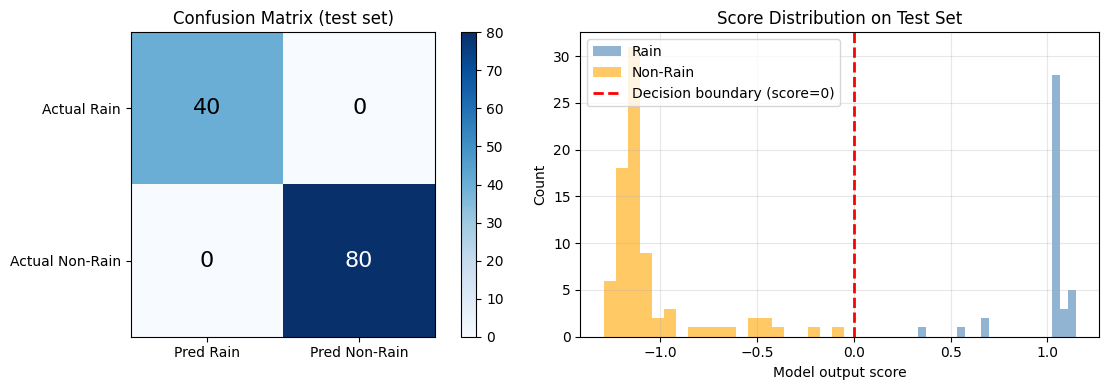


What the score distribution tells us:
  - Overlap near 0 = uncertain predictions (the hard cases)
  - Well-separated peaks = confident correct predictions
  - FP/FN live in the overlap zone


In [24]:
# --- evaluate: confusion matrix tells the real story ---
# Accuracy alone is misleading. We need to know:
#   - False Positives (FP): wind/forest predicted as rain  -> nuisance alerts
#   - False Negatives (FN): rain predicted as non-rain     -> missed detections
# These have very different costs depending on the application!

y_test_scores = [audio_model(x).data for x in xs_test]
y_test_pred   = [1.0 if s > 0 else -1.0 for s in y_test_scores]

# confusion matrix
TP = sum(p== 1 and g== 1 for p,g in zip(y_test_pred, ys_test))
TN = sum(p==-1 and g==-1 for p,g in zip(y_test_pred, ys_test))
FP = sum(p== 1 and g==-1 for p,g in zip(y_test_pred, ys_test))
FN = sum(p==-1 and g== 1 for p,g in zip(y_test_pred, ys_test))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (TP + TN) / len(ys_test)

print('Confusion Matrix (on held-out TEST set):')
print(f'                 Predicted Rain  Predicted Non-Rain')
print(f'Actual Rain      TP={TP:3d}           FN={FN:3d}   <- missed detections')
print(f'Actual Non-Rain  FP={FP:3d}           TN={TN:3d}   <- false alarms')
print()
print(f'Accuracy:  {accuracy:.1%}')
print(f'Precision: {precision:.1%}  (of predicted rain, how much IS rain?)')
print(f'Recall:    {recall:.1%}  (of actual rain, how much do we catch?)')
print(f'F1 Score:  {f1:.3f}')

# visualize confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

cm = np.array([[TP, FN], [FP, TN]])
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0,1]); ax1.set_yticks([0,1])
ax1.set_xticklabels(['Pred Rain', 'Pred Non-Rain'])
ax1.set_yticklabels(['Actual Rain', 'Actual Non-Rain'])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, cm[i,j], ha='center', va='center', fontsize=16,
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
ax1.set_title('Confusion Matrix (test set)')
plt.colorbar(im, ax=ax1)

# score distribution — where is the decision boundary?
rain_scores    = [s for s, g in zip(y_test_scores, ys_test) if g == 1.0]
nonrain_scores = [s for s, g in zip(y_test_scores, ys_test) if g == -1.0]
ax2.hist(rain_scores,    bins=20, alpha=0.6, label='Rain',     color='steelblue')
ax2.hist(nonrain_scores, bins=20, alpha=0.6, label='Non-Rain', color='orange')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Decision boundary (score=0)')
ax2.set_xlabel('Model output score'); ax2.set_ylabel('Count')
ax2.set_title('Score Distribution on Test Set')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print()
print('What the score distribution tells us:')
print('  - Overlap near 0 = uncertain predictions (the hard cases)')
print('  - Well-separated peaks = confident correct predictions')
print('  - FP/FN live in the overlap zone')


---
## Key Takeaways

### From Lecture 1 (micrograd)
1. **Every neural net is a mathematical expression.** Forward pass = evaluate it. Backward pass = differentiate it.
2. **Chain rule is everything.** Backprop is just the chain rule applied recursively on a computation graph.
3. **`loss.backward()` works because** we built a topological sort of the graph and call `_backward()` in reverse order.
4. **Gradient descent:** `param.data -= lr * param.grad` — move each parameter a tiny step in the direction that decreases the loss.

### Audio Insight
- **Audio features = the inputs to our network.** RMS, spectral centroid, ZCR are signal-level descriptions — interpretable, fast to compute.
- **The same backprop we built from scratch** works on audio features exactly the same way as on any other data.
- **Later in the course** (WaveNet lecture!) we'll see how to skip hand-crafted features and let the network learn its own representations directly from raw audio.

### Next step
- Lecture 2: [makemore](https://www.youtube.com/watch?v=PaCmpygFfXo) — bigram language model → **audio analogy:** bigram model over quantized audio frames / MIDI notes